In [1]:
import json
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import mujoco as mj
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, wilcoxon

from ariel.body_phenotypes.robogen_lite.constructor import construct_mjspec_from_graph
from ariel.simulation.environments import SimpleFlatWorld
from ariel.utils.renderers import single_frame_renderer
from ea_body import genotype_to_graph, load_targets

HERE = Path.cwd()
DATA = HERE.parents[1] / "__data__" / "A1"
OUT = HERE / "results"
OUT.mkdir(exist_ok=True)
assert DATA.exists(), f"no experiment data at {DATA}"

BG = "#f7f4f0"

sns.set_theme(style="ticks")
mpl.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 400,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "STIX Two Text", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 8,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9.5,
        "axes.labelcolor": "#444444",
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "text.color": "#1a1a1a",
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "xtick.color": "#444444",
        "ytick.color": "#444444",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#dddddd",
        "grid.linewidth": 0.6,
        "grid.linestyle": "--",
        "legend.fontsize": 7.5,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#cccccc",
        "legend.framealpha": 1.0,
        "legend.labelcolor": "#1a1a1a",
        "legend.handlelength": 1.8,
        "legend.labelspacing": 0.35,
        "lines.linewidth": 1.2,
    }
)

CONFIGS = ["point", "subtree", "random"]
LABELS = {
    "point": "Point mutation (P)",
    "subtree": "Subtree mutation (S)",
    "random": "Random search",
}
SHORT = {"point": "Point", "subtree": "Subtree", "random": "Random"}
COLORS = {
    "point": "#2255cc",
    "subtree": "#cc4422",
    "random": "#5b5b5b",
    "target": "#888888",
}
DASHED = (0, (4, 1.5))
DOTTED = (0, (1, 1.5))
COL_W, PAGE_W = 3.35, 7.0
H2_GEN = 10


def panel_title(ax, text):
    """Italic serif panel title."""
    ax.set_title(text, color="#1a1a1a", fontfamily="serif", fontstyle="italic", pad=6)

In [2]:
frames = []
for config in CONFIGS:
    for f in sorted((DATA / config).glob("seed_*/generations.csv")):
        run = pd.read_csv(f)
        run["config"] = config
        run["seed"] = int(f.parent.name.split("_")[1])
        frames.append(run)
df = pd.concat(frames, ignore_index=True)

last = df.groupby(["config", "seed"]).tail(1)
assert (
    last["gen"].nunique() == 1 and last["evals"].nunique() == 1
), "incomplete or unequal runs"
last.groupby("config").agg(
    runs=("seed", "size"), last_gen=("gen", "first"), evals=("evals", "first")
).reindex(CONFIGS)

,runs,last_gen,evals
config,,,
point,20,100,10100
subtree,20,100,10100
random,20,100,10100


In [3]:
final = last.set_index(["config", "seed"])["best"]
summary = (
    final.groupby("config")
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        min="min",
        max="max",
    )
    .reindex(CONFIGS)
)
summary.to_csv(OUT / "final_best.csv")
summary.round(3)

,n,mean,std,median,q1,q3,min,max
config,,,,,,,,
point,20,13.533,0.346,13.490,13.310,13.719,12.719,14.165
subtree,20,12.340,0.393,12.300,12.034,12.551,11.774,13.302
random,20,14.294,0.205,14.284,14.250,14.406,13.641,14.588


In [4]:
def a12(x, y):
    x = np.asarray(x, dtype=float)[:, None]
    y = np.asarray(y, dtype=float)[None, :]
    return float(((x < y).sum() + 0.5 * (x == y).sum()) / (x.size * y.size))


def holm(p):
    p = np.asarray(p, dtype=float)
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, i in enumerate(np.argsort(p, kind="stable")):
        running = max(running, min(1.0, (len(p) - rank) * p[i]))
        adjusted[i] = running
    return adjusted


assert a12([1, 2, 3], [4, 5, 6]) == 1.0 and a12([1], [1, 2]) == 0.75
assert np.allclose(holm([0.01, 0.04, 0.03]), [0.03, 0.06, 0.06])


def best_at(config, gen=None):
    """Final best fitness per seed, or the best fitness at a given generation."""
    rows = last if gen is None else df[df["gen"] == gen]
    return rows[rows["config"] == config].sort_values("seed")["best"].to_numpy()


COMPARISONS = [
    ("final best", "subtree", "point", None),
    ("final best", "point", "random", None),
    ("final best", "subtree", "random", None),
    (f"best at gen {H2_GEN}", "subtree", "point", H2_GEN),
]

rows = []
for name, x, y, gen in COMPARISONS:
    vx, vy = best_at(x, gen), best_at(y, gen)
    signed = wilcoxon(vx, vy)
    unpaired = mannwhitneyu(vx, vy, alternative="two-sided")
    rows.append(
        {
            "test": name,
            "X": SHORT[x],
            "Y": SHORT[y],
            "n_pairs": len(vx),
            "W": signed.statistic,
            "p_paired": signed.pvalue,
            "A12 P(X<Y)": a12(vx, vy),
            "X better in": int((vx < vy).sum()),
            "p_mwu_unpaired": unpaired.pvalue,
        }
    )
tests = pd.DataFrame(rows)
tests["p_holm"] = holm(tests["p_paired"])
tests.to_csv(OUT / "tests.csv", index=False)
tests

,test,X,Y,n_pairs,W,p_paired,A12 P(X<Y),X better in,p_mwu_unpaired,p_holm
0,final best,Subtree,Point,20,0.0,0.000002,0.9850,20,1.648290e-07,0.000008
1,final best,Point,Random,20,0.0,0.000002,0.9775,20,2.556344e-07,0.000008
2,final best,Subtree,Random,20,0.0,0.000002,1.0000,20,6.757379e-08,0.000008
3,best at gen 10,Subtree,Point,20,47.0,0.029575,0.6900,15,4.112359e-02,0.029575


In [5]:
def profiles(config, gen):
    """Per-target distances of the best body of each run, shape (runs, 5)."""
    rows = df[(df["config"] == config) & (df["gen"] == gen)].sort_values("seed")
    return rows[[f"best_d{i}" for i in range(5)]].to_numpy()


LAST_GEN = int(df["gen"].max())
rows = []
for gen in (H2_GEN, LAST_GEN):
    for config in ("point", "subtree"):
        p = profiles(config, gen)
        mean_d, sigma_d = p.mean(axis=1), p.std(axis=1)
        rows.append(
            {
                "gen": gen,
                "config": SHORT[config],
                "mean_d": mean_d.mean(),
                "sigma_d": sigma_d.mean(),
                "fitness": (mean_d + sigma_d).mean(),
                **{f"d{i + 1}": p[:, i].mean() for i in range(5)},
            }
        )
decomposition = pd.DataFrame(rows)

for gen in (H2_GEN, LAST_GEN):
    p_point, p_subtree = profiles("point", gen), profiles("subtree", gen)
    for term, values in (
        ("mean_d", (p_point.mean(axis=1), p_subtree.mean(axis=1))),
        ("sigma_d", (p_point.std(axis=1), p_subtree.std(axis=1))),
    ):
        vp, vs = values
        p_value = wilcoxon(vs, vp).pvalue
        decomposition.loc[decomposition["gen"] == gen, f"p_paired_{term}"] = p_value

diversity = last.groupby("config")["unique_genotypes"].mean().reindex(CONFIGS[:2])
decomposition["unique_genotypes_final"] = decomposition["config"].map(
    {SHORT[c]: diversity[c] for c in CONFIGS[:2]}
)
decomposition.to_csv(OUT / "decomposition.csv", index=False)
decomposition.round(3)

,gen,config,mean_d,sigma_d,fitness,d1,d2,d3,d4,d5,p_paired_mean_d,p_paired_sigma_d,unique_genotypes_final
0,10,Point,11.660,2.233,13.893,9.350,10.000,11.025,12.800,15.125,0.386,0.024,4.25
1,10,Subtree,11.775,1.881,13.656,10.125,10.425,10.925,12.575,14.825,0.386,0.024,62.25
2,100,Point,11.540,1.993,13.533,9.500,10.050,11.075,12.450,14.625,0.204,0.000,4.25
3,100,Subtree,11.715,0.625,12.340,11.100,11.350,11.450,12.150,12.525,0.204,0.000,62.25


In [6]:
ea = df[(df["config"] != "random") & (df["gen"] > 0)]
guard = ea.groupby("config")[["size_rejections", "size_fallbacks"]].sum().astype(int)
start = df[df["gen"] == 0].set_index(["config", "seed"])["evals"]
end = last.set_index(["config", "seed"])["evals"]
guard["offspring"] = (end - start).groupby("config").sum()
guard.to_csv(OUT / "size_guard.csv")
guard

,size_rejections,size_fallbacks,offspring
config,,,
point,0,0,200000
subtree,3,0,200000


In [7]:
pd.read_csv(OUT / "step_size.csv").round(3)

,parents,operator,n,mean_abs_d_nodes,mean_abs_d_fitness,median_abs_d_fitness,noop_rate,growth_rate,shrink_rate,over_cap_rate
0,ramped,replace_node (P),1000,0.783,0.440,0.283,0.000,0.000,0.276,0.000
1,ramped,subtree_replacement (S),1000,1.297,0.521,0.336,0.060,0.199,0.348,0.012
2,ramped,shrink,1000,1.208,0.459,0.249,0.100,0.000,0.437,0.000
3,ramped,hoist,1000,1.854,0.629,0.482,0.088,0.000,0.912,0.000
4,full21,replace_node (P),1000,1.308,0.713,0.346,0.000,0.000,0.336,0.000
5,full21,subtree_replacement (S),1000,2.138,1.021,0.578,0.074,0.197,0.424,0.197
6,full21,shrink,1000,1.955,0.894,0.385,0.085,0.000,0.491,0.000
7,full21,hoist,1000,2.752,1.253,0.879,0.000,0.000,1.000,0.000


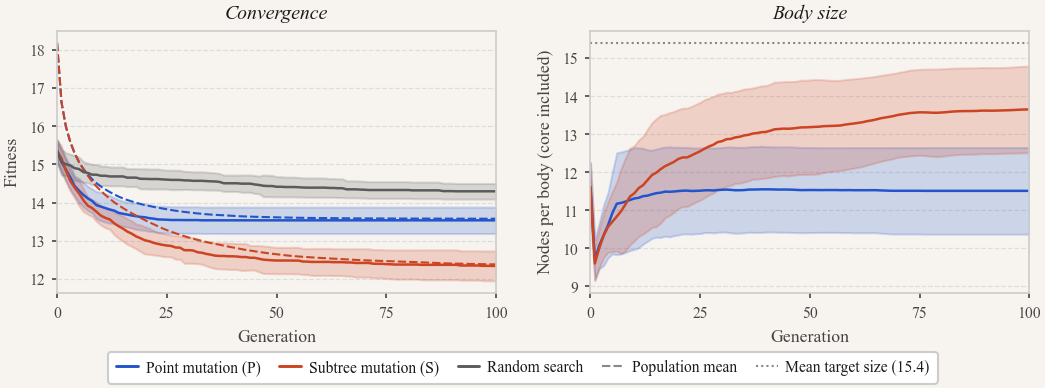

In [8]:
fig, (ax_fit, ax_size) = plt.subplots(1, 2, figsize=(PAGE_W, 2.6), sharex=True)
for config in CONFIGS:
    runs = df[df["config"] == config]
    sns.lineplot(
        data=runs,
        x="gen",
        y="best",
        color=COLORS[config],
        errorbar="sd",
        legend=False,
        ax=ax_fit,
    )
    if config != "random":
        sns.lineplot(
            data=runs,
            x="gen",
            y="mean",
            color=COLORS[config],
            errorbar=None,
            linestyle=DASHED,
            linewidth=1.0,
            legend=False,
            ax=ax_fit,
        )
        sns.lineplot(
            data=runs,
            x="gen",
            y="mean_size",
            color=COLORS[config],
            errorbar="sd",
            legend=False,
            ax=ax_size,
        )

target_mean = float(np.mean([t.number_of_nodes() for t in load_targets()]))
ax_size.axhline(target_mean, color=COLORS["target"], linestyle=DOTTED, linewidth=1.0)

panel_title(ax_fit, "Convergence")
panel_title(ax_size, "Body size")
ax_fit.set_ylabel("Fitness")
ax_size.set_ylabel("Nodes per body (core included)")

handles = [Line2D([], [], color=COLORS[c], lw=1.4, label=LABELS[c]) for c in CONFIGS]
handles.append(
    Line2D([], [], color="#888888", lw=1.0, linestyle=DASHED, label="Population mean")
)
handles.append(
    Line2D(
        [],
        [],
        color=COLORS["target"],
        lw=1.0,
        linestyle=DOTTED,
        label=f"Mean target size ({target_mean:.1f})",
    )
)


for ax in (ax_fit, ax_size):
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("Generation")
fig.tight_layout(pad=0.4, w_pad=1.8, rect=(0, 0.09, 1, 1))
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5,
    handlelength=1.4,
    handletextpad=0.5,
    columnspacing=1.2,
    borderpad=0.5,
)
fig.savefig(OUT / "fig1_dynamics.png")
fig.savefig(OUT / "fig1_dynamics.pdf")
plt.show()

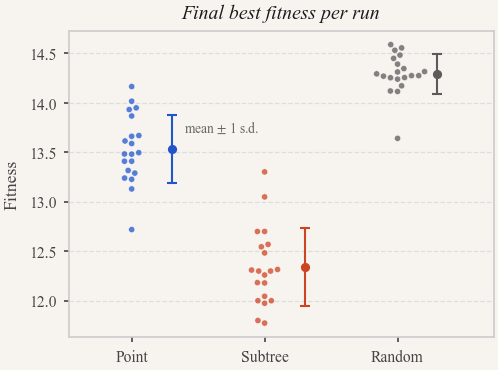

In [9]:
order = [SHORT[c] for c in CONFIGS]
palette = {SHORT[c]: COLORS[c] for c in CONFIGS}
final_df = last.assign(method=last["config"].map(SHORT))

fig, ax = plt.subplots(figsize=(COL_W, 2.5))
sns.swarmplot(
    data=final_df,
    x="method",
    y="best",
    order=order,
    hue="method",
    hue_order=order,
    palette=palette,
    size=3.0,
    alpha=0.75,
    linewidth=0.3,
    edgecolor="white",
    legend=False,
    ax=ax,
)
for i, config in enumerate(CONFIGS):
    values = final.loc[config]
    ax.errorbar(
        i + 0.30,
        values.mean(),
        yerr=values.std(),
        color=COLORS[config],
        marker="o",
        markersize=3.4,
        elinewidth=1.0,
        capsize=2.2,
        capthick=1.0,
        linestyle="none",
        zorder=5,
    )

panel_title(ax, "Final best fitness per run")
ax.set(xlabel="", ylabel="Fitness")
ax.margins(x=0.18)
ax.annotate(
    "mean $\\pm$ 1 s.d.",
    xy=(0.30, final.loc["point"].mean()),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=6.5,
    color="#666666",
)
fig.tight_layout(pad=0.4)
fig.savefig(OUT / "fig2_final_best.png")
fig.savefig(OUT / "fig2_final_best.pdf")
plt.show()

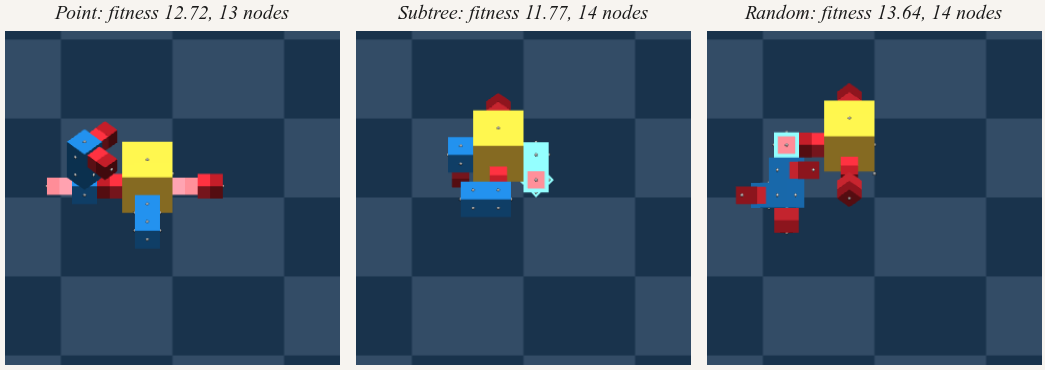

In [10]:
best_runs = (
    last.loc[last.groupby("config")["best"].idxmin()]
    .set_index("config")
    .reindex(CONFIGS)
)

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, 2.4))
for ax, (config, row) in zip(axes, best_runs.iterrows()):
    payload = json.loads(
        (
            DATA / config / f"seed_{int(row['seed']):02d}" / "best_genome.json"
        ).read_text()
    )
    mj.set_mjcb_control(None)
    world = SimpleFlatWorld()
    robot = construct_mjspec_from_graph(genotype_to_graph(payload["genotype"]))
    world.spawn(robot.spec, position=[0.0, 0.0, 0.1], correct_collision_with_floor=True)
    model = world.spec.compile()
    data = mj.MjData(model)
    mj.mj_forward(model, data)
    image = single_frame_renderer(
        model,
        data,
        width=640,
        height=640,
        cam_fovy=2.0,
        save=True,
        save_path=str(OUT / f"best_body_{config}.png"),
    )
    w, h = image.size
    ax.imshow(image.crop((w * 0.25, h * 0.25, w * 0.75, h * 0.75)))
    panel_title(
        ax,
        f"{SHORT[config]}: fitness {row['best']:.2f}, {payload['num_nodes']} nodes",
    )
    ax.set_axis_off()
fig.tight_layout(pad=0.4, w_pad=1.0)
fig.savefig(OUT / "fig3_best_bodies.png")
fig.savefig(OUT / "fig3_best_bodies.pdf")
plt.show()